## 17 ANN
### ARTIFICIAL NEURAL NETWORKS
By **Mohan Sirumalla**
***

### 1. Data Exploration and Preprocessing
 * Begin by loading and exploring the "Alphabets_data.csv" dataset. Summarize its key features such as the number of samples, features, and classes.
 * Execute necessary data preprocessing steps including data normalization, managing missing values.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay
from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [54]:
df = pd.read_csv('18_sonardataset.csv')
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [55]:
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())


First 5 rows of the dataset:
      x_1     x_2     x_3     x_4     x_5     x_6     x_7     x_8     x_9  \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

     x_10  ...    x_52    x_53    x_54    x_55    x_56    x_57    x_58  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

     x_59    x_60  Y  
0  0.0090  0.0032  R  
1  0.0052  0.0044

In [5]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

No Duplicates
No null values found in the DataFrame.


In [7]:
(df.isnull().sum()/len(df))*100

x_1     0.0
x_2     0.0
x_3     0.0
x_4     0.0
x_5     0.0
       ... 
x_57    0.0
x_58    0.0
x_59    0.0
x_60    0.0
Y       0.0
Length: 61, dtype: float64

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [58]:
df.columns

Index(['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10',
       'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19',
       'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28',
       'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37',
       'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46',
       'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55',
       'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'Y'],
      dtype='object')

In [59]:
df['Y'].unique()

array(['R', 'M'], dtype=object)

In [60]:
# getting some useful characteristics of the dataset
print(f"The dataset contains {len(df)} samples and {len(df.columns) - 1} features.")
display(df.head())  # visualizing some samples

The dataset contains 208 samples and 60 features.


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R




We can notice that the standard deviations (std) are quite high, showing that the data is greatly dispersed around the mean. It is commonly believed that features with low variance contributes little to the model performance and with high variance contributes more. However this is far from truth because this notion disconsiders that features might come in different units (e.g. meters and millimeters) that might differ greatly in terms of mean and std values. However, these features can be important even in a narrow range when predicting the outcome of a model.


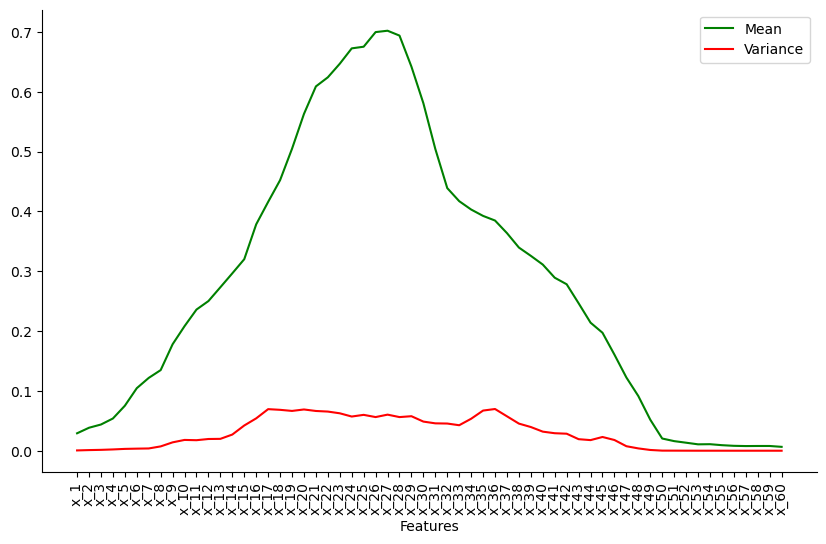

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_var = df.var(numeric_only=True, skipna=True)
feat_mean = df.mean(numeric_only=True, skipna=True)
plt.figure(figsize=(10,6))
disp = sns.lineplot(data=feat_mean, color="g", legend="brief", label="Mean")
disp = sns.lineplot(data=feat_var, color="r", legend="brief", label="Variance")
disp.set_xlabel("Features")
sns.despine()  # remove top and right spines
plt.xticks(rotation=90)
plt.show()

Checking if it is a balanced dataset. Imbalanced datasets are bad for model training because the model becomes biased towards the majority label.

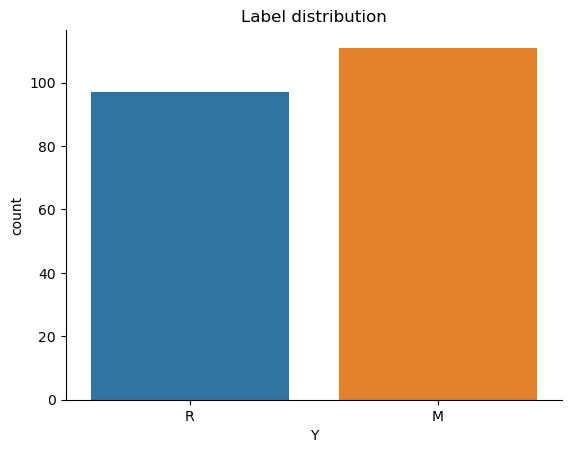

In [62]:
sns.countplot(x="Y",hue="Y" ,data=df).set_title("Label distribution")
sns.despine()
plt.show()



The labels' distribution is almost balanced. We can also take a look at some density estimates of three variables. Instead of using an histogram to approximate the probability density function, we will use kernel density estimation (KDE) that "smooths" the histogram and present a continuous density estimate.

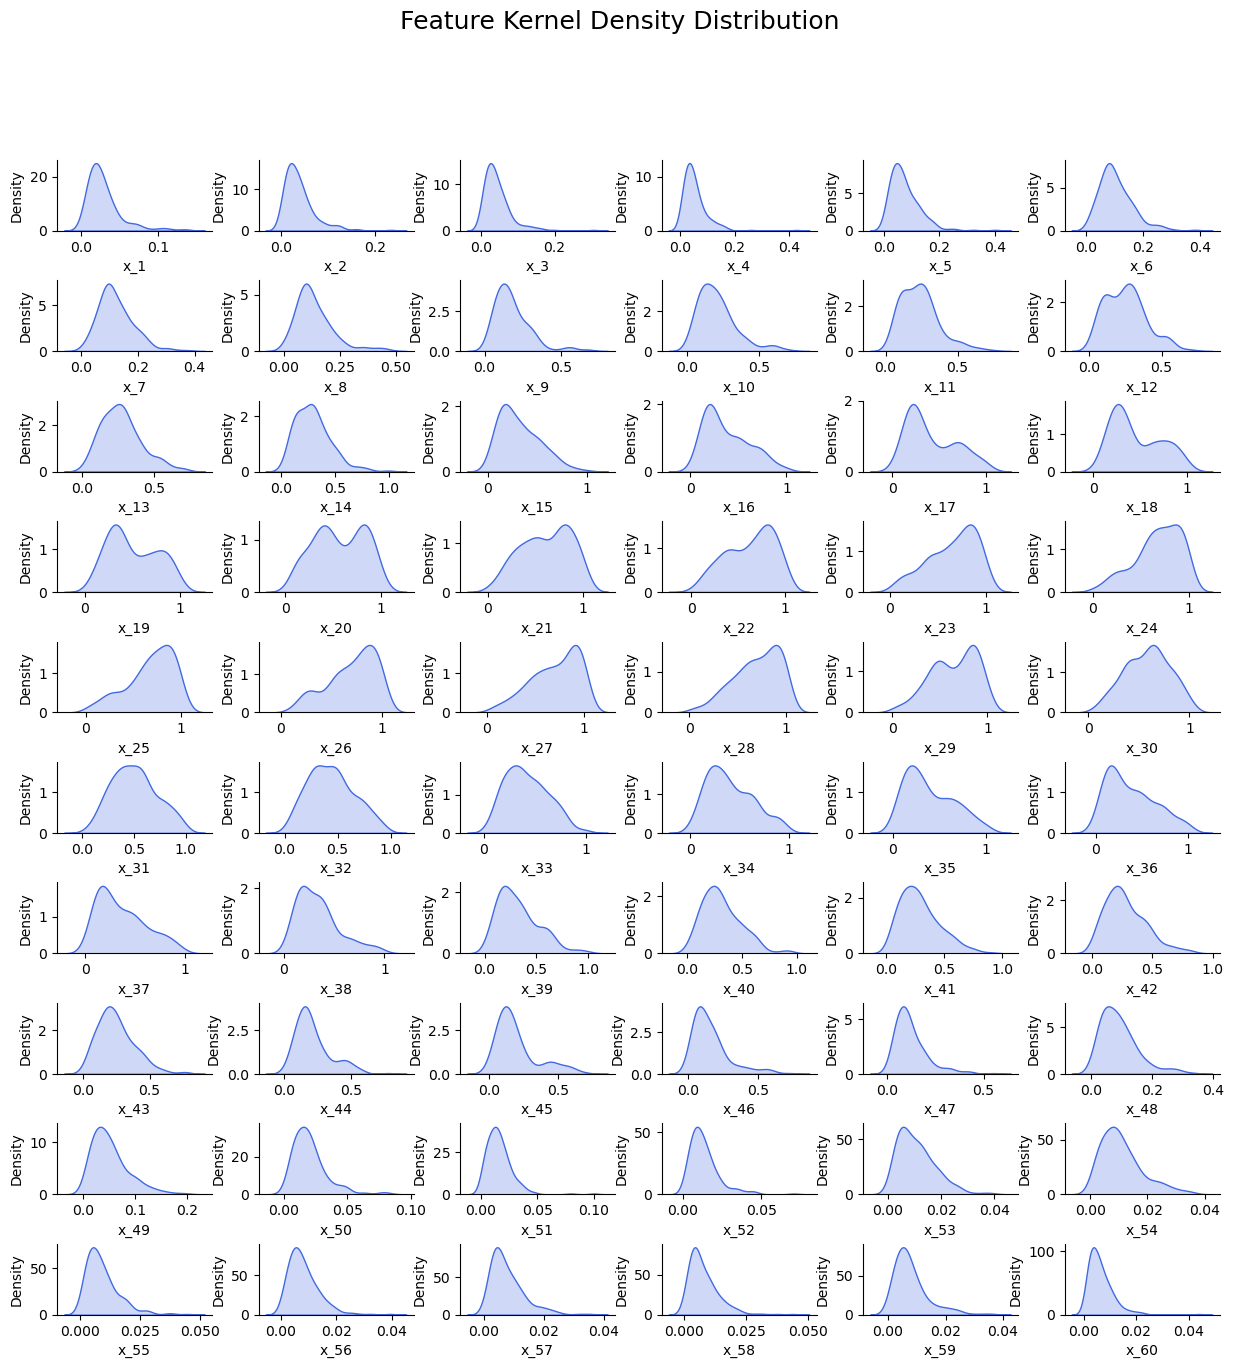

In [19]:
# creating subplots
fig, axs = plt.subplots(10, 6, figsize=(15, 15))
plt.subplots_adjust(hspace=0.7, wspace=0.3)
plt.suptitle("Feature Kernel Density Distribution", fontsize=18)
sns.despine()

# iterating through dataset to plot in axes
for feat, ax in zip(df.columns, axs.ravel()):
    sns.kdeplot(data=df[feat], fill=True, ax=ax, color="royalblue")
plt.show()




Checking the relationship between some randomly choosen features.


Pearson's correlation coefficient: R=0.736, P=0.000


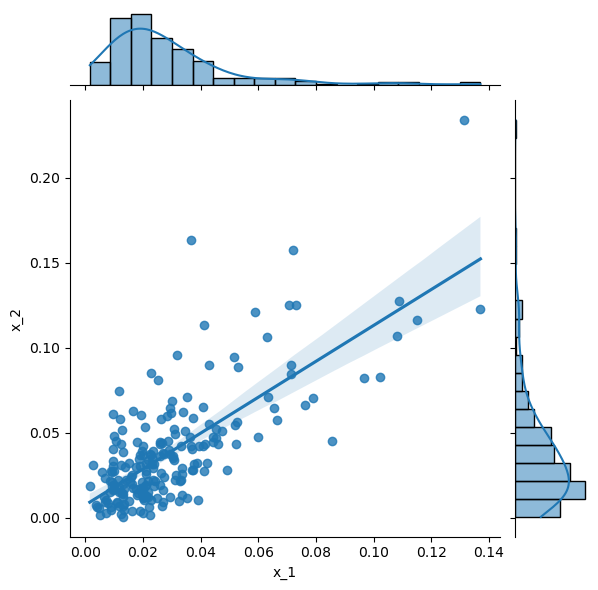

In [21]:
from scipy import stats

# Pearson's correlation coefficient
r, p = stats.pearsonr(x=df["x_1"], y=df["x_2"])
print("Pearson's correlation coefficient: R={:.3f}, P={:.3f}".format(r, p))

disp = sns.jointplot(data=df, x="x_1", y="x_2", kind="reg")
plt.show()

Pearson's correlation coefficient: R=-0.428, P=0.000


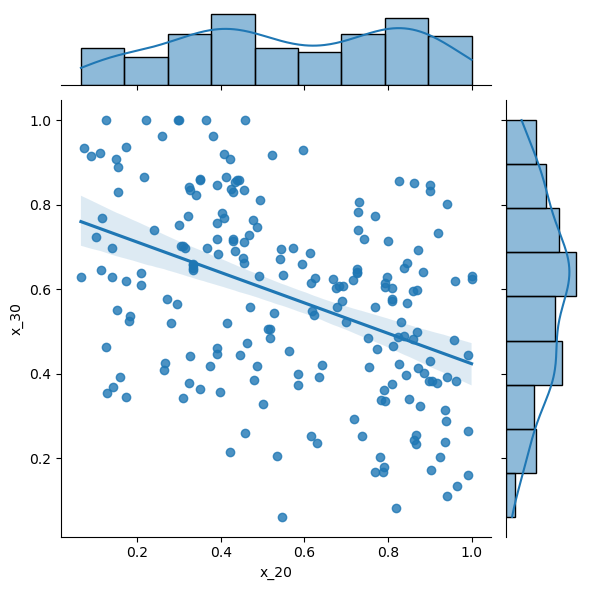

In [22]:
# Pearson's correlation coefficient
r, p = stats.pearsonr(x=df["x_20"], y=df["x_30"])
print("Pearson's correlation coefficient: R={:.3f}, P={:.3f}".format(r, p))

disp = sns.jointplot(data=df, x="x_20", y="x_30", kind="reg")
plt.show()



It seems that we have some highly correlated features. Some of these features could be excluded from training to get a simpler and lighter classification model. Eliminating highly correlated features can make our dataset less "noisy" and our model simpler. A correlation heatmap plot can show correlated variables and the correlation degree, direction (positive or negative correlation).

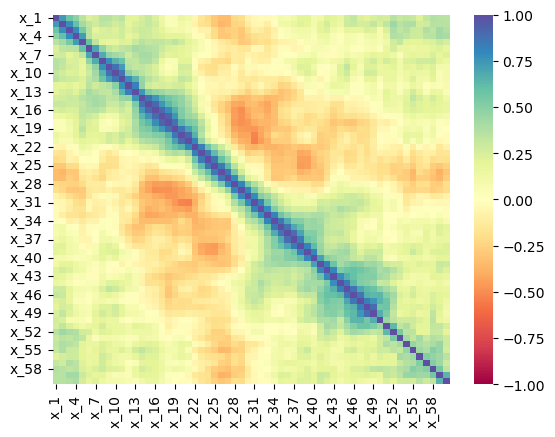

In [23]:
df_corr = df.corr(numeric_only=True)  # numeric_only excludes the target label column
heatplot = sns.heatmap(data=df_corr, vmin=-1, vmax=1, cmap="Spectral")
plt.show()

In [24]:
import numpy as np

# get the mask (upper half of correlation matrix, absolute)
upper = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
display(upper.head())

# filter correlation by threshold
threshold = 1
cols_to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print(
    f"There are {len(cols_to_drop)} features with correlation higher than {threshold}."
)

# drop correlated columns
df.drop(columns=cols_to_drop, axis=1, inplace=True)
df.head()

# store the number of remaining features (will be used to define the input size during training)
num_features = len(df.columns) - 1  # features minus label columns
print(f"There are {num_features} remaining in the dataset.")

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
x_1,NaN,0.735896,0.571537,0.491438,0.344797,0.238921,0.260815,0.355523,0.353420,0.318276,...,0.254450,0.355299,0.311729,0.322299,0.312067,0.220642,0.313725,0.368132,0.357116,0.347078
x_2,NaN,NaN,0.779916,0.606684,0.419669,0.332329,0.279040,0.334615,0.316733,0.270782,...,0.320538,0.434548,0.346076,0.383960,0.380165,0.262263,0.280341,0.353042,0.352200,0.358761
x_3,NaN,NaN,NaN,0.781786,0.546141,0.346275,0.190434,0.237884,0.252691,0.219637,...,0.238110,0.394076,0.332914,0.367186,0.289731,0.287661,0.380819,0.334108,0.425047,0.373948
x_4,NaN,NaN,NaN,NaN,0.726943,0.352805,0.246440,0.246742,0.247078,0.237769,...,0.174676,0.374651,0.364772,0.334211,0.284955,0.280938,0.340254,0.344865,0.420266,0.400626
x_5,NaN,NaN,NaN,NaN,NaN,0.597053,0.335422,0.204006,0.177906,0.183219,...,0.115936,0.266617,0.314985,0.205306,0.196472,0.199323,0.219395,0.238793,0.290982,0.253710


There are 0 features with correlation higher than 1.
There are 60 remaining in the dataset.


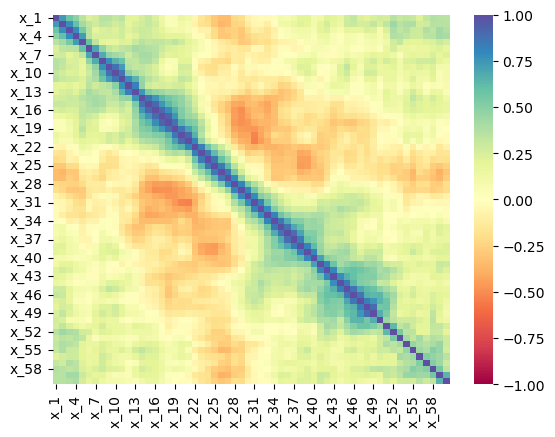

In [25]:
sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, cmap="Spectral")
plt.show()



First, lets split the training data into a feature matrix and a target label vector. Here we convert the labels into numbers using LabelEncoder

In [29]:
!pip3 install torch torchvision torchaudio

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 1.0/113.8 MB 6.1 MB/s eta 0:00:19
    --------------------------------------- 2.1/113.8 MB 5.5 MB/s eta 0:00:21
   - -------------------------------------- 3.4/113.8 MB 5.9 MB/s eta 0:00:19
   - -------------------------------------- 4.7/113.8 MB 6.0 MB/s eta 0:00:19
   -- ------------------------------------- 5.8/113.8 MB 5.9 MB/s eta 0:00:19
   -- ------------------------------------- 6.6/113.8 MB 5.7 MB/s eta 0:00:19
   -- ------------------------------------- 7.9/113.8 MB 5.6 MB/s eta 0:00:19
   --- ------------------------------------ 9.4/113.8 MB 5.8 MB/s eta 0:00:19
   --- ------------------------------------ 11.0/113.8 MB 5.9 MB/s eta 0:00:18
   ---- ----------------------------------- 12.3/113.8 MB 6.0 MB/s eta 0:00:17
   ---- ----------------------------------- 13.6/113.8 MB 6.1 MB/s eta 0:00:17
   ----- ---------------------------------- 14.9/113.8 MB 6.1 MB/s e

### 2. Model Implementation

* Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.
* Divide the dataset into training and test sets.
* Train your model on the training set and then use it to make predictions on the test set.

In [66]:
print("--- Data Preprocessing ---")

# 1. Encoding the categorical 'object_class' target variable
le = LabelEncoder()
y = le.fit_transform(df['Y'])
print("Target variable 'Y' encoded successfully.")
print("Class mapping: ", list(le.classes_), "->", list(le.transform(le.classes_)))

# 2. Separating features (X) from the target variable (y)
X = df.drop('Y', axis=1)
print("Features (X) and target (y) separated.")

# 3. Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Dataset split into training and testing sets.")

# 4. Scaling numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Numerical features scaled using StandardScaler.")

# 5. Print the shapes of the resulting datasets
print("\nShapes after preprocessing:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

--- Data Preprocessing ---
Target variable 'Y' encoded successfully.
Class mapping:  ['M', 'R'] -> [np.int64(0), np.int64(1)]
Features (X) and target (y) separated.
Dataset split into training and testing sets.
Numerical features scaled using StandardScaler.

Shapes after preprocessing:
X_train shape: (166, 60)
X_test shape: (42, 60)
y_train shape: (166,)
y_test shape: (42,)


#### Baseline Model Training - Logistic Regression

In [68]:
print("--- Training Logistic Regression Model ---")

# 1. Instantiate a LogisticRegression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
print("Logistic Regression model instantiated.")

# 2. Perform 5-fold cross-validation
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')
print("5-fold cross-validation performed.")

# 3. Report the mean and standard deviation of the cross-validation accuracy scores
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

# 4. Fit the Logistic Regression model to the entire scaled training data
log_reg_model = log_reg.fit(X_train, y_train)
print("Logistic Regression model trained on the full training data.")

--- Training Logistic Regression Model ---
Logistic Regression model instantiated.
5-fold cross-validation performed.
Cross-validation accuracy scores: [0.76470588 0.72727273 0.72727273 0.78787879 0.81818182]
Mean CV Accuracy: 0.7651
Standard Deviation of CV Accuracy: 0.0352
Logistic Regression model trained on the full training data.


#### Baseline Model Training - Random Forest

In [69]:
print("--- Training Random Forest Classifier Model ---")

# 1. Instantiate a RandomForestClassifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
print("Random Forest Classifier model instantiated.")

# 2. Perform 5-fold cross-validation
rf_cv_scores = cross_val_score(rf_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("5-fold cross-validation performed.")

# 3. Report the mean and standard deviation of the cross-validation accuracy scores
print(f"Cross-validation accuracy scores: {rf_cv_scores}")
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {rf_cv_scores.std():.4f}")

# 4. Fit the RandomForestClassifier model to the entire scaled training data
rf_model = rf_classifier.fit(X_train, y_train)
print("Random Forest Classifier model trained on the full training data.")

--- Training Random Forest Classifier Model ---
Random Forest Classifier model instantiated.
5-fold cross-validation performed.
Cross-validation accuracy scores: [0.85294118 0.81818182 0.72727273 0.87878788 0.87878788]
Mean CV Accuracy: 0.8312
Standard Deviation of CV Accuracy: 0.0565
Random Forest Classifier model trained on the full training data.


In [70]:
print("--- Training XGBoost Classifier Model ---")

# 1. Instantiate an XGBClassifier model
# use_label_encoder=False and eval_metric='mlogloss' are set to suppress deprecation warnings and for multi-class classification.
xgb_classifier = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
print("XGBoost Classifier model instantiated.")

# 2. Perform 5-fold cross-validation
xgb_cv_scores = cross_val_score(xgb_classifier, X_train, y_train, cv=5, scoring='accuracy')
print("5-fold cross-validation performed.")

# 3. Report the mean and standard deviation of the cross-validation accuracy scores
print(f"Cross-validation accuracy scores: {xgb_cv_scores}")
print(f"Mean CV Accuracy: {xgb_cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {xgb_cv_scores.std():.4f}")

# 4. Fit the XGBoost Classifier model to the entire scaled training data
xgb_model = xgb_classifier.fit(X_train, y_train)
print("XGBoost Classifier model trained on the full training data.")

--- Training XGBoost Classifier Model ---
XGBoost Classifier model instantiated.
5-fold cross-validation performed.
Cross-validation accuracy scores: [0.88235294 0.87878788 0.75757576 0.90909091 0.93939394]
Mean CV Accuracy: 0.8734
Standard Deviation of CV Accuracy: 0.0619
XGBoost Classifier model trained on the full training data.


In [ ]:
## Model Evaluation and Visualization - Logistic Regression

--- Evaluating Logistic Regression Model ---
Predictions made on the test set.

Logistic Regression Accuracy: 0.8333

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           M       0.78      0.95      0.86        22
           R       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



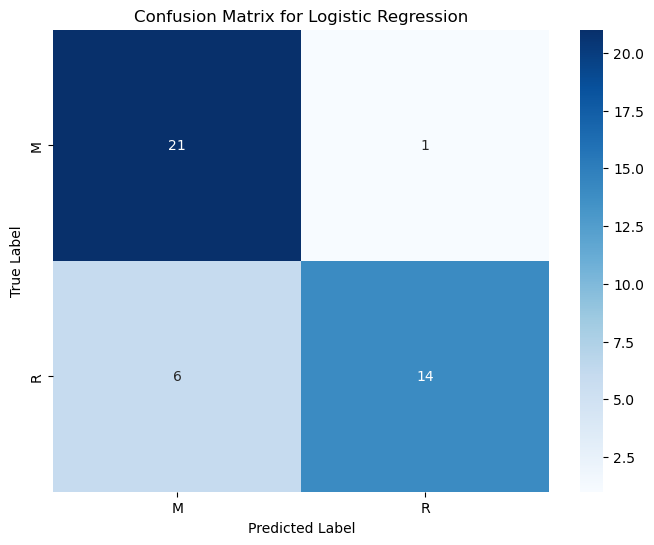

Probability predictions computed for ROC curve.
----------------
['M' 'R']
check


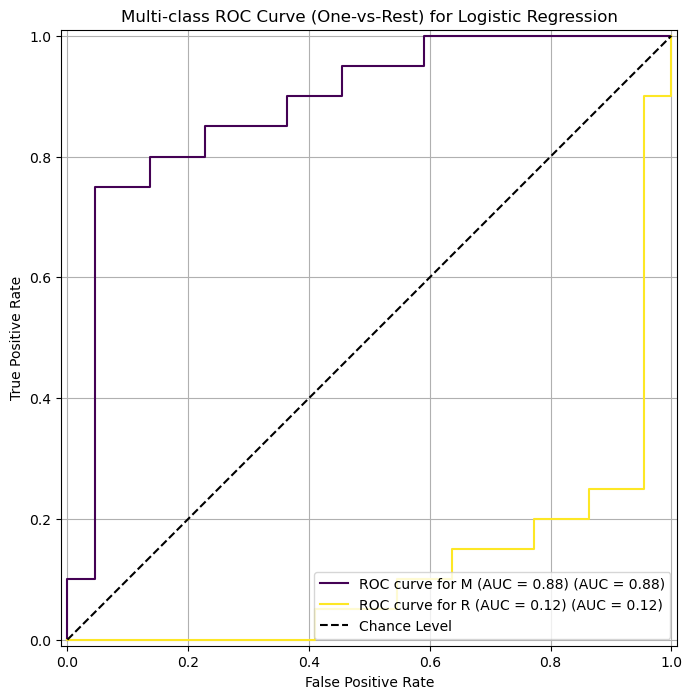

Logistic Regression model evaluation complete.


In [76]:
from sklearn.metrics import accuracy_score, roc_curve, auc, RocCurveDisplay # Added accuracy_score and explicitly re-importing ROC related for clarity in this block
from sklearn.preprocessing import LabelBinarizer # Needed for One-vs-Rest ROC curve

print("--- Evaluating Logistic Regression Model ---")

# 1. Make predictions on the scaled test set
y_pred_log_reg = log_reg_model.predict(X_test)
print("Predictions made on the test set.")

# 2. Calculate and display the accuracy score
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"\nLogistic Regression Accuracy: {accuracy_log_reg:.4f}")

# 3. Generate and print a classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=le.classes_))

# 4. Generate and visualize a confusion matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Compute the probability predictions for each class on X_test
y_proba_log_reg = log_reg_model.predict_proba(X_test)
print("Probability predictions computed for ROC curve.")

# 6. For each class, plot the One-vs-Rest ROC curve and calculate its AUC
plt.figure(figsize=(10, 8))

# Binarize the output for One-vs-Rest ROC
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
print("----------------")
# Initialize ax for plotting
ax = plt.gca()
print(le.classes_)
print("check")
for i in range(len(le.classes_)):
    # Calculate fpr, tpr, and roc_auc for the current class BEFORE using them in the label
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i-1], y_proba_log_reg[:, i-1])
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i-1],
        y_proba_log_reg[:, i-1],
        name=f"ROC curve for {le.classes_[i]} (AUC = {roc_auc:.2f})", # Use calculated roc_auc
        color=plt.cm.get_cmap('viridis', len(le.classes_))(i),
        ax=ax, # Plot all curves on the same axes
        plot_chance_level=False # Plot chance level manually once later
    )

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level') # Plot chance level once
plt.title('Multi-class ROC Curve (One-vs-Rest) for Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Logistic Regression model evaluation complete.")

--- Evaluating Random Forest Classifier Model ---
Predictions made on the test set.

Random Forest Classifier Accuracy: 0.8810

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           M       0.81      1.00      0.90        22
           R       1.00      0.75      0.86        20

    accuracy                           0.88        42
   macro avg       0.91      0.88      0.88        42
weighted avg       0.90      0.88      0.88        42



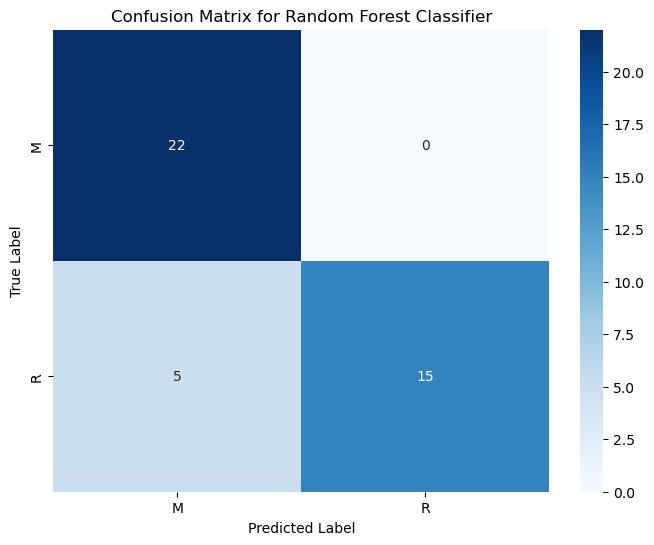

Probability predictions computed for ROC curve.


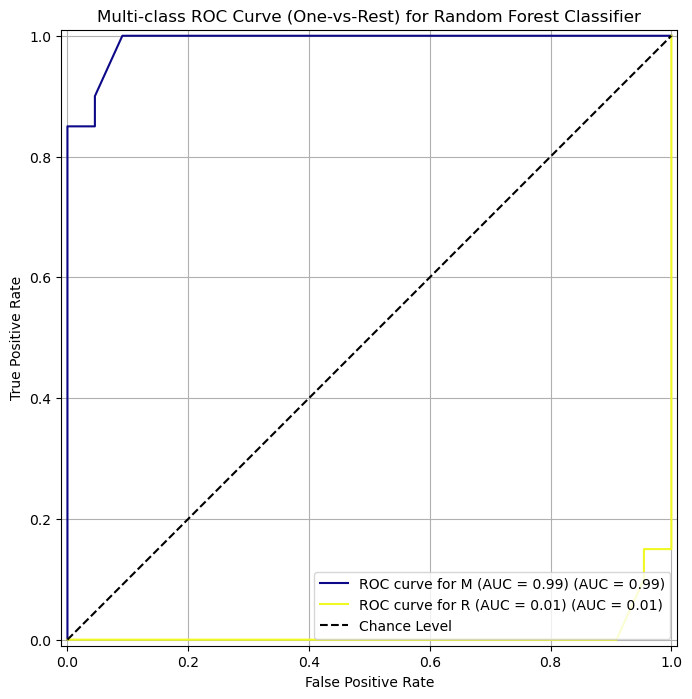

Random Forest Classifier model evaluation complete.


In [78]:
print("--- Evaluating Random Forest Classifier Model ---")

# 1. Make predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test)
print("Predictions made on the test set.")

# 2. Calculate and display the accuracy score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Classifier Accuracy: {accuracy_rf:.4f}")

# 3. Generate and print a classification report
print("\nRandom Forest Classifier Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# 4. Generate and visualize a confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Compute the probability predictions for each class on X_test
y_proba_rf = rf_model.predict_proba(X_test)
print("Probability predictions computed for ROC curve.")

# 6. For each class, plot the One-vs-Rest ROC curve and calculate its AUC
plt.figure(figsize=(10, 8))

# Binarize the output for One-vs-Rest ROC
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)

# Initialize ax for plotting
ax = plt.gca()

for i in range(len(le.classes_)):
    # Calculate fpr, tpr, and roc_auc for the current class BEFORE using them in the label
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i-1], y_proba_rf[:, i-1])
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i-1],
        y_proba_rf[:, i-1],
        name=f"ROC curve for {le.classes_[i]} (AUC = {roc_auc:.2f})", # Use calculated roc_auc
        color=plt.cm.get_cmap('plasma', len(le.classes_))(i),
        ax=ax, # Plot all curves on the same axes
        plot_chance_level=False # Plot chance level manually once later
    )

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level') # Plot chance level once
plt.title('Multi-class ROC Curve (One-vs-Rest) for Random Forest Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Random Forest Classifier model evaluation complete.")

In [26]:
from sklearn.preprocessing import LabelEncoder

# split into features' vector and labels vector
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encoding labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(f"Labels: {encoder.classes_} = [Metal, Rock] encoded into:")
print(y)

Labels: ['M' 'R'] = [Metal, Rock] encoded into:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
# converting features and labels to tensors
import torch

x = torch.tensor(x.values, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print(f"features dim: {x.shape}")
print(f"labels dim: {y.shape}")

features dim: torch.Size([208, 60])
labels dim: torch.Size([208, 1])


In [31]:
# defining the wide neural network structure (a single hidden layer)

import torch.nn as nn


# The neural network child class is derived from nn.Module base class
# In the constructor, declare all the layers of the network
class Wide(nn.Module):
    # instantiate all modules (their attributes and methods)
    def __init__(self):
        # initialize attributes and methods of the parent class
        super().__init__()
        # input layer for 60 variables (60 units or neurons) and 180 output units
        self.hidden = nn.Linear(in_features=num_features, out_features=180)
        # activation of the layer (breaking linearity)
        self.relu = nn.ReLU()
        # the output is a real number for binary classification...
        self.output = nn.Linear(in_features=180, out_features=1)
        # ...and the sigmoid takes the input (1) tensor and squeeze (reescale) it to [0,1] range
        # representing the probability of the target label of a given sample.
        # class 1 = P, class 2 = 1 - P(class 1)
        # Note: sigmoid is used for binary classification, softmax is an extension of sigmoid for multiclass problems
        self.sigmoid = nn.Sigmoid()

    # the forward function defines the neural network structure, with
    # number of units (neurons), activations, regularizations, outputs...
    # Then, here we define how the network will be run from input to output:
    def forward(self, x):
        # taking the input, computing weigths and applying non-linearity
        x = self.relu(self.hidden(x))
        # taking the output of the previous layer and squeezing it
        # to the range [0,1]
        x = self.sigmoid(self.output(x))
        return x  # x is the probability of class 1, while class 2 is (1-x)


wide_model = Wide()
wide_model

Wide(
  (hidden): Linear(in_features=60, out_features=180, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=180, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [32]:
# defining the deep neural network structure (more than one hidden layer)


class Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=num_features, out_features=60)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(60, 60)
        self.act2 = nn.ReLU()
        self.layer3 = nn.Linear(60, 60)
        self.act3 = nn.ReLU()
        self.output = nn.Linear(60, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.act3(self.layer3(x))
        x = self.sigmoid(self.output(x))
        return x


# instantiate the models and move them to the GPU
deep_model = Deep()
deep_model

Deep(
  (layer1): Linear(in_features=60, out_features=60, bias=True)
  (act1): ReLU()
  (layer2): Linear(in_features=60, out_features=60, bias=True)
  (act2): ReLU()
  (layer3): Linear(in_features=60, out_features=60, bias=True)
  (act3): ReLU()
  (output): Linear(in_features=60, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [33]:
# testing the data flow through the the networks with random data
# the result will be around 0.5 probability because the network
# isn't trained yet and data is just blah blah blah for the model.
random_data = torch.rand(num_features)
print(random_data)

result_wide = wide_model(random_data)
result_deep = deep_model(random_data)

print(f"\nResult Wide: {result_wide}")
print(f"Result Deep: {result_deep}")

tensor([0.6834, 0.4560, 0.6025, 0.0088, 0.3763, 0.0517, 0.2961, 0.9498, 0.2920,
        0.3801, 0.9674, 0.2228, 0.7376, 0.6125, 0.6025, 0.1981, 0.9253, 0.9384,
        0.6262, 0.8972, 0.4109, 0.4495, 0.4766, 0.4332, 0.7996, 0.5674, 0.4510,
        0.8266, 0.6236, 0.7251, 0.0199, 0.6432, 0.8110, 0.5258, 0.0420, 0.5660,
        0.6846, 0.9473, 0.7855, 0.7515, 0.5836, 0.1781, 0.2003, 0.2173, 0.9192,
        0.9458, 0.1245, 0.3634, 0.7527, 0.3419, 0.3680, 0.1384, 0.7846, 0.0439,
        0.5798, 0.3956, 0.5401, 0.2099, 0.9164, 0.3261])

Result Wide: tensor([0.5458], grad_fn=<SigmoidBackward0>)
Result Deep: tensor([0.4961], grad_fn=<SigmoidBackward0>)


Defining the FNN training loop

After defining the network attributes and the forward method we can create the training loop, which will feed batches of data to the model, get the output to calculate the loss and using this loss in the backward pass to update the learnable parameters (i.e. weights and biases) of the network in each iteration (batch).


The loss function calculates the difference between the predicted output and the ground truth labels. The optimizer adjust the parameters of the network towards minimization of the difference between the predictions and the actual labels.

we define both the loss function and optimizers in the training loop to instantiate them in each iteration, allowing unbiased comparison between the performance of the models.

### 3. Hyperparameter Tuning

* Modify various hyperparameters, such as the number of hidden layers, neurons per hidden layer, activation functions, and learning rate, to observe their impact on model performance.
* Adopt a structured approach like grid search or random search for hyperparameter tuning, documenting your methodology thoroughly.


In [34]:
from tqdm.notebook import tqdm_notebook
import copy

# tqdm makes it easy to implement a progress bar
# to monitor the training status and time
tqdm_notebook.pandas()


def model_train(model, x_train, y_train, x_test, y_test, n_epochs=250, batch_size=10):
    # two labels, binary cross-entropy loss
    criterion = nn.BCELoss()
    # Adam is a stochastic gradient descent optimizer
    # that requires little memory and parameter tuning
    optim = torch.optim.Adam(model.parameters(), lr=0.0001)

    batch_start = torch.arange(start=0, end=len(x_train), step=batch_size)

    # keeps the best model
    best_acc = -np.inf  # starting at negative infinity
    best_weights = None  # hold the best learnt parameters

    # training loop (epoch counter)
    for epoch in range(n_epochs):
        model.train()  # set the model to training mode (e.g. activates dropout layers)
        with tqdm_notebook(
            batch_start, unit="batch", mininterval=0, disable=True
        ) as bar:
            bar.set_description(f"Epoch: {epoch}")
            for start in bar:
                # get the batch
                x_batch = x_train[start : start + batch_size]
                y_batch = y_train[start : start + batch_size]
                # FNN forward pass: obtain predictions and loss of each training batch
                y_pred = model(x_batch)  # predicts labels for training batch
                loss = criterion(y_pred, y_batch)  # calculate the loss of the batch
                # FNN backward pass:
                optim.zero_grad()  # zero the parameter gradients of previous runs
                loss.backward()  # accumulates dloss/dx for every parameter that requires_grad=True
                # update weigths using the accumulated loss stored in parameter_x.grad
                optim.step()
                # print training progress (accuracy and loss).
                # using accuracy but for highly imbalanced datasets use balanced accuracy
                # compute metrics after the optimization step to obtain metrics for the batch
                acc = (y_pred.round() == y_batch).float().mean()
                bar.set_postfix(loss=float(loss), acc=float(acc))

        # calculates the accuracy after each epoch, i.e. when
        # all the training data have passed through the network.
        # model.eval(): turns off parts of the model (e.g. dropout layers)
        # used for training that aren't used in inference mode
        # torch.no_grad(): disable autograd and may speed up computation
        model.eval()
        with torch.no_grad():
            y_pred = model(x_test)
            acc = float((y_pred.round() == y_test).float().mean())
            if acc > best_acc:
                best_acc = acc
                best_weights = copy.deepcopy(model.state_dict())
    # returns the best model (based on the best accuracy)
    model.load_state_dict(best_weights)
    return best_acc

k-fold Cross-Validation

With the data preprocessed and the network architectures on hands, we can carry out a competition between these two approaches to determine the best estimator.

Here we will seek the how accurate are the predictions of a test set after a number of iterations between these two models. The metrics will be recorded for later evaluation, but the best model can be used right the way because we will encode its instatiation and training.

In [35]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_idx, test_idx) in enumerate(kfold.split(x, y)):
    print(f"Fold {i}:")
    print(f"    Train:  index={train_idx[:10]}")
    print(f"    Test:   index={test_idx[:10]}")

Fold 0:
    Train:  index=[ 0  1  2  4  5  6  7 10 11 12]
    Test:   index=[ 3  8  9 15 17 23 26 28 34 38]
Fold 1:
    Train:  index=[0 1 2 3 4 5 6 7 8 9]
    Test:   index=[10 13 16 24 25 31 32 37 40 43]
Fold 2:
    Train:  index=[ 0  2  3  4  5  6  8  9 10 11]
    Test:   index=[ 1  7 12 14 20 35 42 47 59 61]
Fold 3:
    Train:  index=[ 1  2  3  4  5  7  8  9 10 12]
    Test:   index=[ 0  6 11 19 21 22 29 36 39 54]
Fold 4:
    Train:  index=[ 0  1  3  6  7  8  9 10 11 12]
    Test:   index=[ 2  4  5 18 27 30 33 45 56 58]


In [36]:
from sklearn.model_selection import StratifiedKFold, train_test_split

# split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, shuffle=True, random_state=123)

# setting kfold parameters
kfold = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# lists to hold the cross-validation scores
n_epochs = 250
cv_scores_wide = []
cv_scores_deep = []

# kfold-split loops for each model
fold_counter = 0
for train_index, test_index in kfold.split(x_train, y_train):
    model = Wide()
    acc = model_train(
        model,
        x_train[train_index],
        y_train[train_index],
        x_train[test_index],
        y_train[test_index],
        n_epochs=n_epochs,
    )
    fold_counter += 1
    print(f"Fold {fold_counter}")
    print("Accuracy Wide Model: {:.2%}".format(acc))
    cv_scores_wide.append(acc)

fold_counter = 0
for train_index, test_index in kfold.split(x_train, y_train):
    model = Deep()
    acc = model_train(
        model,
        x_train[train_index],
        y_train[train_index],
        x_train[test_index],
        y_train[test_index],
        n_epochs=n_epochs,
    )
    fold_counter += 1
    print(f"Fold {fold_counter}")
    print("Accuracy Deep Model: {:.2%}".format(acc))
    cv_scores_deep.append(acc)

# printing scores of both nets
acc_wide, std_wide = np.mean(cv_scores_wide), np.std(cv_scores_wide)
acc_deep, std_deep = np.mean(cv_scores_deep), np.std(cv_scores_deep)
print("\nAccuracy Wide Model: {:.2%} (+/- {:.2%})".format(acc_wide, std_wide))
print("Accuracy Deep Model: {:.2%} (+/- {:.2%})".format(acc_deep, std_deep))

C:\Users\DELL\AppData\Local\Temp\ipykernel_19140\2334048645.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bar.set_postfix(loss=float(loss), acc=float(acc))


Fold 1
Accuracy Wide Model: 79.31%
Fold 2
Accuracy Wide Model: 79.31%
Fold 3
Accuracy Wide Model: 86.21%
Fold 4
Accuracy Wide Model: 82.76%
Fold 5
Accuracy Wide Model: 79.31%
Fold 1
Accuracy Deep Model: 82.76%
Fold 2
Accuracy Deep Model: 82.76%
Fold 3
Accuracy Deep Model: 86.21%
Fold 4
Accuracy Deep Model: 89.66%
Fold 5
Accuracy Deep Model: 93.10%

Accuracy Wide Model: 81.38% (+/- 2.76%)
Accuracy Deep Model: 86.90% (+/- 4.02%)


In [ ]:
Now that we have a decision on the best model, we can retrain the network using all the training data.

In [37]:
model = Deep()
acc = model_train(model, x_train, y_train, x_test, y_test)
print("Accuracy Deep Model: {:.2%}".format(acc))

Accuracy Deep Model: 85.71%


### 4. Evaluation

* Employ suitable metrics such as accuracy, precision, recall, and F1-score to evaluate your model's performance.
* Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.

In [38]:
import random

model.eval()
with torch.no_grad():
    for idx in range(5):
        # generates a random index in x_test index range
        rnd_int = sum(random.sample(range(0, len(x_test)), k=1))
        prediction = model(x_test[rnd_int]).detach().numpy()
        print(
            "Sample {} label: {} \nPredicted label: {}. (output: {}).\n".format(
                rnd_int, y_test[rnd_int].round(), prediction.round(), prediction
            )
        )

Sample 43 label: tensor([0.]) 
Predicted label: [0.]. (output: [0.27865168]).

Sample 43 label: tensor([0.]) 
Predicted label: [0.]. (output: [0.27865168]).

Sample 55 label: tensor([1.]) 
Predicted label: [1.]. (output: [0.98336095]).

Sample 32 label: tensor([1.]) 
Predicted label: [1.]. (output: [0.7481001]).

Sample 29 label: tensor([1.]) 
Predicted label: [1.]. (output: [0.87408805]).



Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88        36
         1.0       0.88      0.78      0.82        27

    accuracy                           0.86        63
   macro avg       0.86      0.85      0.85        63
weighted avg       0.86      0.86      0.86        63



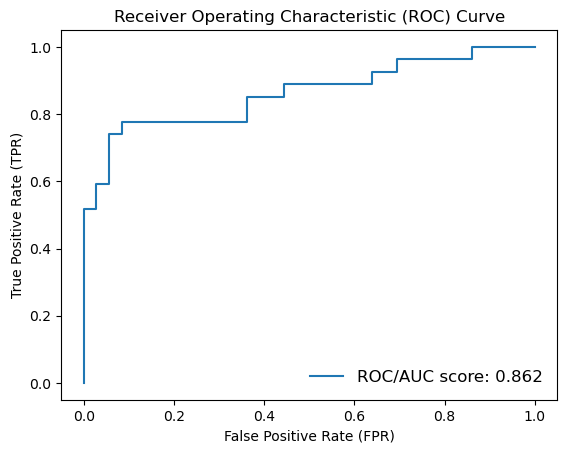

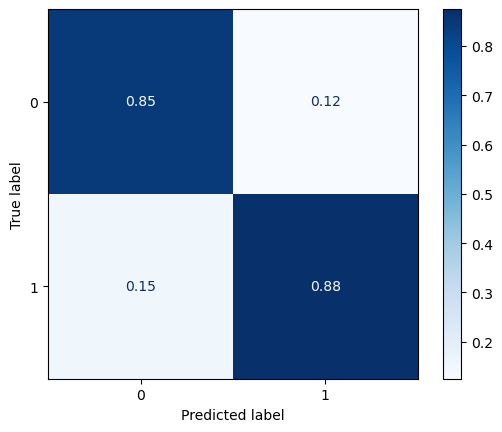

In [39]:
from sklearn.metrics import (roc_curve,
                             roc_auc_score,
                             ConfusionMatrixDisplay,
                             confusion_matrix,
                             classification_report
                            )
                            

# predict testing set labels
y_pred = model(x_test)

# remove computational graph from tensor and convert to numpy array
y_pred = y_pred.ravel().detach().numpy()

# print classification report
print(f"Classification Report:\n{classification_report(y_test, y_pred.round())}")

# get ROC and AUC score
fpr, tpr, _ = roc_curve(y_test, y_pred)
score = roc_auc_score(y_test, y_pred)
plt.plot(fpr, tpr)
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.ylabel("True Positive Rate (TPR)")
plt.xlabel("False Positive Rate (FPR)")

# add custom legend with AUC score
score = "ROC/AUC score: " + str(score.round(decimals=3))
plt.legend(labels=[score], loc="lower right", edgecolor="w", fontsize=12)
plt.show()

# confusion matrix
cm = confusion_matrix(y_test.ravel().detach().numpy(), y_pred.round(), normalize="pred")
cm = ConfusionMatrixDisplay(cm).plot(cmap="Blues")

In the classification report, the metrics are:

    Precision: True Positives divided by the total of positive samples predicted by the model. Measures how the model get the right label among the ones predicted as positive.

    Recall (also called sensitivity or true positive rate (tpr)): True Positives divided by all positive samples in the input (i.e. ground-truth positives). Measures how


Logistic Regression

What about the classic statistical learning models? They do a pretty good job in most commonly found problem scenarios in the market. Let's see if Logistic Regression or Support Vector Machine (SVM) classifiers beat the deep learning model.

Let's try these out-of-the-box models and then search for the best hyperparameters using GridSearchCV or RandomizedSearchCV from Sklearn. Before that, we convert PyTorch tensors, that has additional characteristics (e.g. computational graph to compute gradients in the FNN) to NumPy arrays for Sklearn algorithms.

In [41]:
# detach computational graph and convert to ndarray
x_train, y_train = x_train.detach().numpy(), y_train.ravel().detach().numpy()
x_test, y_test = x_test.detach().numpy(), y_test.ravel().detach().numpy()

print(f"Types x {type(x_train)} and y {type(y_train)}.")
print(f"Types x {type(x_test)} and y {type(y_test)}.")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

Types x <class 'numpy.ndarray'> and y <class 'numpy.ndarray'>.
Types x <class 'numpy.ndarray'> and y <class 'numpy.ndarray'>.
x_train shape: (145, 60)
y_train shape: (145,)
x_test shape: (63, 60)
y_test shape: (63,)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        36
         1.0       0.80      0.74      0.77        27

    accuracy                           0.81        63
   macro avg       0.81      0.80      0.80        63
weighted avg       0.81      0.81      0.81        63



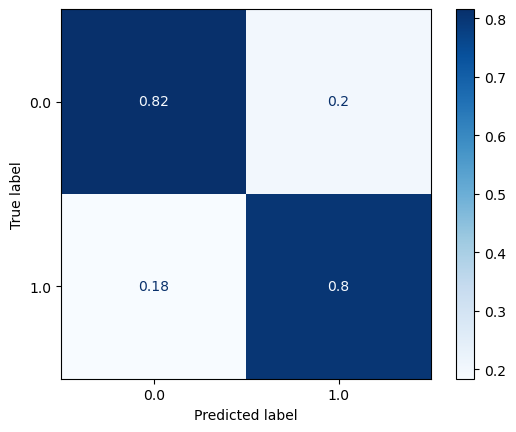

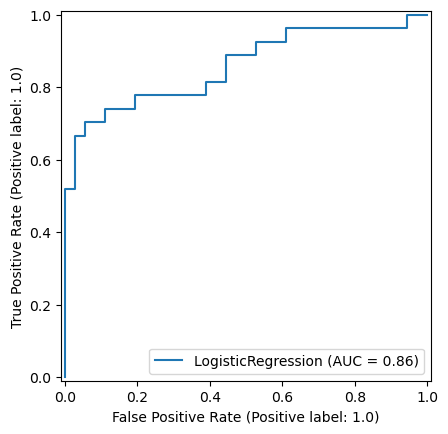

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

clf = LogisticRegression(random_state=42)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
cm = ConfusionMatrixDisplay.from_estimator(clf, x_test, y_test, cmap="Blues", normalize="pred")
disp = RocCurveDisplay.from_estimator(clf, x_test, y_test)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# just ignoring sklearn warnings for this code
import warnings
warnings.filterwarnings("ignore")

# instantiate the classifier
clf = LogisticRegression(random_state=42, verbose=0)

# define parameters' options dictionary for tunning
params = {
    "penalty": [None, "l2", "l1", "elasticnet"],
    "C": np.logspace(-3, 3, 8),
    "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    # "max_iter": [100, 250, 500],
    "warm_start": [True, False],
    "l1_ratio": np.logspace(-1, 0, 8)
}

grid = GridSearchCV(estimator=clf, param_grid=params, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03]),
                         'l1_ratio': array([0.1       , 0.13894955, 0.19306977, 0.26826958, 0.37275937,
       0.51794747, 0.71968567, 1.        ]),
                         'penalty': [None, 'l2', 'l1', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga'],
                         'warm_start': [True, False]})

GridSearchCV best parameters: {'C': np.float64(2.6826957952797246), 'l1_ratio': np.float64(0.1), 'penalty': 'l2', 'solver': 'newton-cholesky', 'warm_start': True}
GridSearchCV best score: 0.7793103448275861
GridSearchCV best estimator: LogisticRegression(C=np.float64(2.6826957952797246), l1_ratio=np.float64(0.1),
                   random_state=42, solver='newton-cholesky', warm_start=True)
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84        36
         1.0       0.80      0.74      0.77        27

    accuracy                           0.81        63
   macro avg       0.81      0.80      0.80        63
weighted avg       0.81      0.81      0.81        63



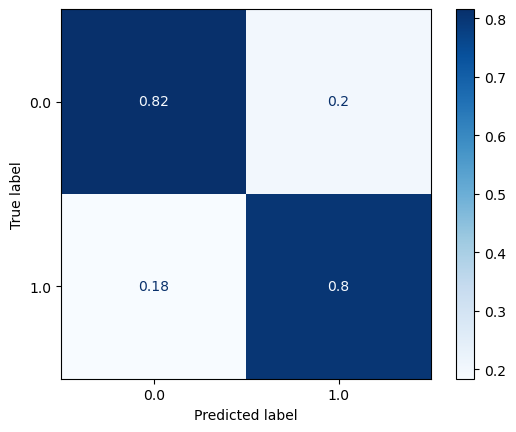

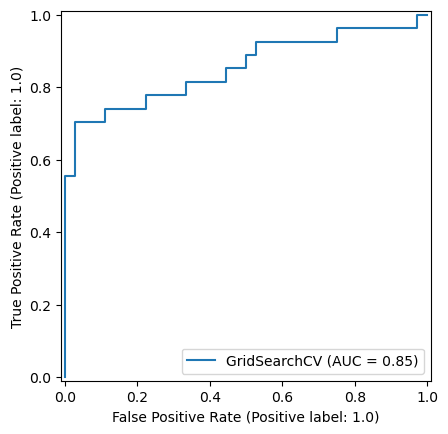

In [44]:
print(f"GridSearchCV best parameters: {grid.best_params_}")
print(f"GridSearchCV best score: {grid.best_score_}")
print(f"GridSearchCV best estimator: {grid.best_estimator_}")

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

cm = ConfusionMatrixDisplay.from_estimator(grid, x_test, y_test, normalize="pred", cmap="Blues")

disp = RocCurveDisplay.from_estimator(grid, x_test, y_test)

Machine learning models can be thought as functions where you plug in input values and get back the output, which can be a vector of label probabilities or a continuous value in regressions. In classification, the function determines a contour in the input feature space. We can visualize how the data points are distributed across this boundary.

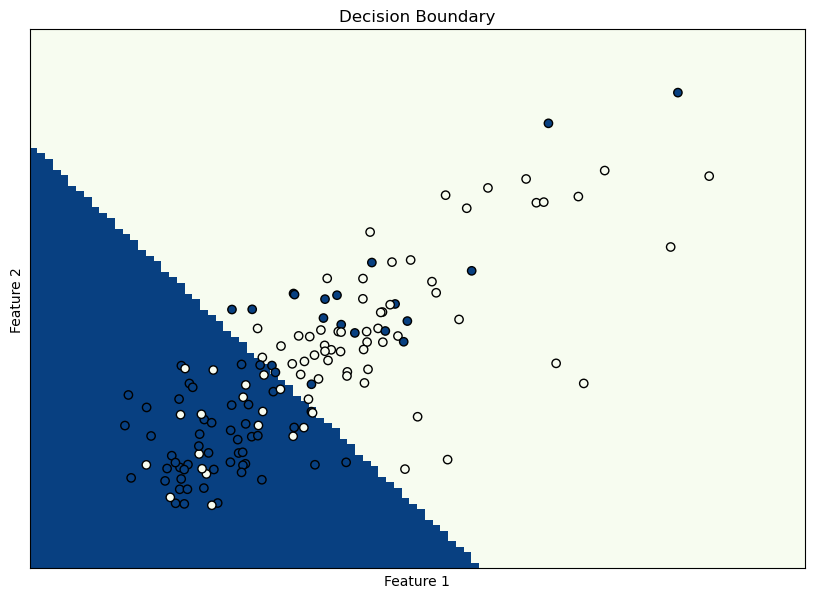

In [45]:
from sklearn.inspection import DecisionBoundaryDisplay

clf = LogisticRegression(random_state=42)

clf.fit(
    x_train[:, 10:12], y_train
)  # only two features from the dataset to plot the decision boundary
_, ax = plt.subplots(figsize=(10, 7))

DecisionBoundaryDisplay.from_estimator(
    clf,
    x_train[:, 10:12],
    response_method="predict",
    cmap="GnBu",
    ax=ax,
    plot_method="pcolormesh",
    shading="auto",
    xlabel="Feature 1",
    ylabel="Feature 2",
    eps=0.1,
)

plt.scatter(x_train[:, 10], x_train[:, 11], c=y_train, edgecolors="k", cmap="GnBu")

plt.title("Decision Boundary")
plt.xticks(())
plt.yticks(())

plt.show()


Support Vector Machine (SVM)

Starting with the out-of-the-box model without any hyperparameter tunning. Just the default determined by Sklearn team:


Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        36
         1.0       0.91      0.74      0.82        27

    accuracy                           0.86        63
   macro avg       0.87      0.84      0.85        63
weighted avg       0.86      0.86      0.85        63



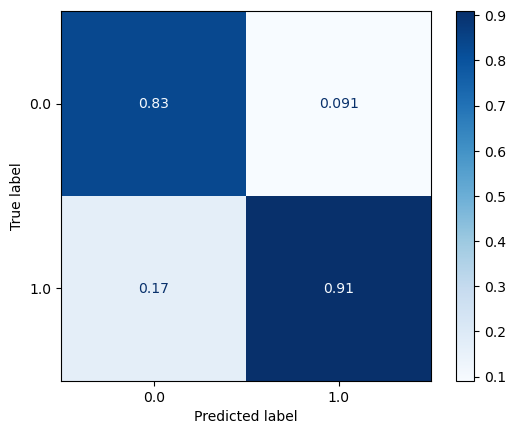

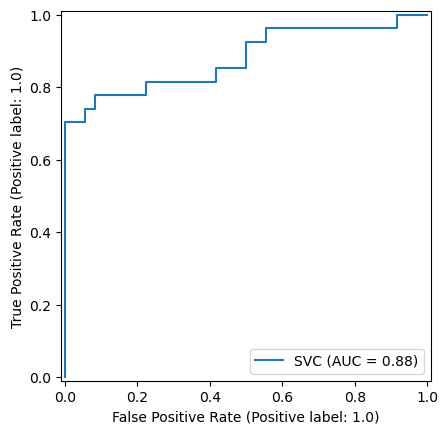

In [46]:
from sklearn.svm import SVC

clf = SVC(random_state=42)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
cm = ConfusionMatrixDisplay.from_estimator(clf, x_test, y_test, normalize="pred", cmap="Blues")
disp = RocCurveDisplay.from_estimator(clf, x_test, y_test)

Again lets search a grid for the best hyperparameters for the SVC classifier:

In [47]:
# instantiating SVC classifier with fixed random seed for reproducibility
clf = SVC(random_state=42)

# defines parameters' grid
params = {
    "C": np.logspace(-3, 3, 8),
    "gamma": np.logspace(-3, 3, 8),
}
print(params)

grid = GridSearchCV(clf, param_grid=params, cv=5)
grid.fit(x_train, y_train)

{'C': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03]), 'gamma': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03])}


GridSearchCV(cv=5, estimator=SVC(random_state=42),
             param_grid={'C': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03])})

GridSearchCV best parameters: {'C': np.float64(19.306977288832496), 'gamma': np.float64(0.3727593720314938)}
GridSearchCV best score: 0.8137931034482758
GridSearchCV best estimator: SVC(C=np.float64(19.306977288832496), gamma=np.float64(0.3727593720314938),
    random_state=42)
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        36
         1.0       0.91      0.74      0.82        27

    accuracy                           0.86        63
   macro avg       0.87      0.84      0.85        63
weighted avg       0.86      0.86      0.85        63



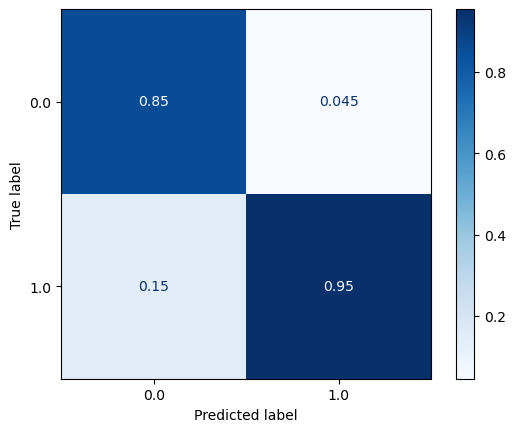

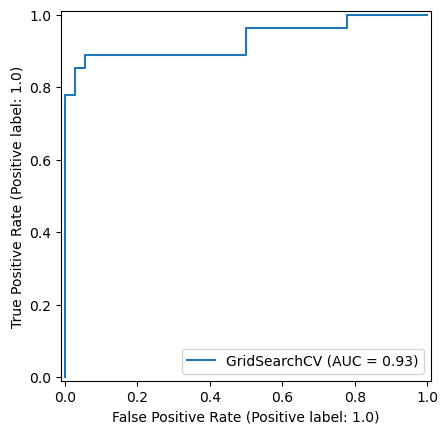

In [48]:
print(f"GridSearchCV best parameters: {grid.best_params_}")
print(f"GridSearchCV best score: {grid.best_score_}")
print(f"GridSearchCV best estimator: {grid.best_estimator_}")

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

cm = ConfusionMatrixDisplay.from_estimator(grid, x_test, y_test, normalize="pred", cmap="Blues")

disp = RocCurveDisplay.from_estimator(grid, x_test, y_test)



Not surprisingly, SVC performs very well both with out-of-the-box and tuned hyperparameters. The plenty of regularization is the one to "blame". It would be interesting to check the decision boundary in this case.


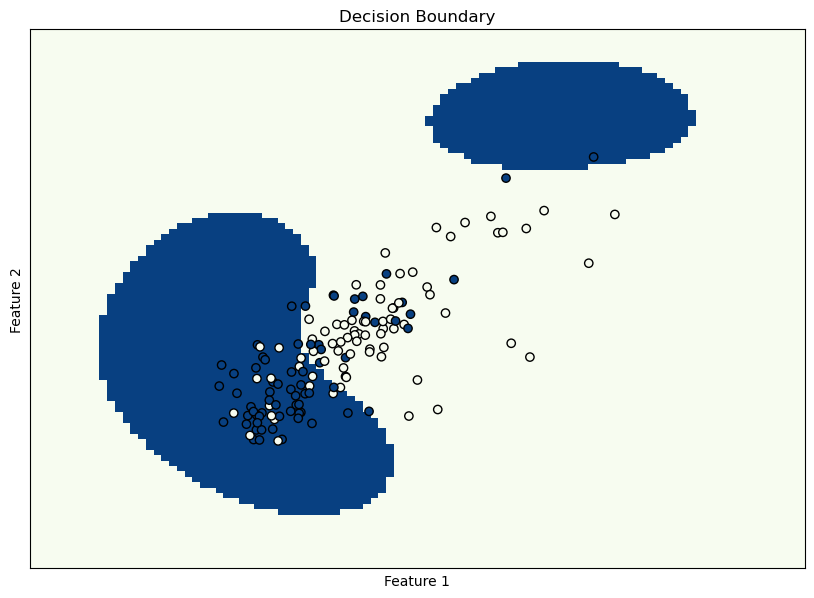

In [49]:
from sklearn.inspection import DecisionBoundaryDisplay

clf = SVC(random_state=42)

clf.fit(
    x_train[:, 10:12], y_train
)  # only two features from the dataset to plot the decision boundary
_, ax = plt.subplots(figsize=(10, 7))

DecisionBoundaryDisplay.from_estimator(
    clf,
    x_train[:, 10:12],
    response_method="predict",
    cmap="GnBu",
    ax=ax,
    plot_method="pcolormesh",
    shading="auto",
    xlabel="Feature 1",
    ylabel="Feature 2",
    eps=0.3,
)

plt.scatter(x_train[:, 10], x_train[:, 11], c=y_train, edgecolors="k", cmap="GnBu")

plt.title("Decision Boundary")
plt.xticks(())
plt.yticks(())

plt.show()

Last things last, making a pipeline that first scales the data and then use the scaled data to train the model.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([("sc", StandardScaler()),
                     ("model", SVC(random_state=42))])

# defines parameters' grid
params = {
    "model__C": np.logspace(-3, 3, 8),
    "model__gamma": np.logspace(-3, 3, 8),
}
print(params)

grid = GridSearchCV(pipe, param_grid=params, cv=5)
grid.fit(x_train, y_train)

{'model__C': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03]), 'model__gamma': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03])}


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('model', SVC(random_state=42))]),
             param_grid={'model__C': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03]),
                         'model__gamma': array([1.00000000e-03, 7.19685673e-03, 5.17947468e-02, 3.72759372e-01,
       2.68269580e+00, 1.93069773e+01, 1.38949549e+02, 1.00000000e+03])})

GridSearchCV best parameters: {'model__C': np.float64(2.6826957952797246), 'model__gamma': np.float64(0.0517947467923121)}
GridSearchCV best score: 0.8413793103448276
GridSearchCV best estimator: Pipeline(steps=[('sc', StandardScaler()),
                ('model',
                 SVC(C=np.float64(2.6826957952797246),
                     gamma=np.float64(0.0517947467923121), random_state=42))])

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        36
         1.0       0.91      0.74      0.82        27

    accuracy                           0.86        63
   macro avg       0.87      0.84      0.85        63
weighted avg       0.86      0.86      0.85        63



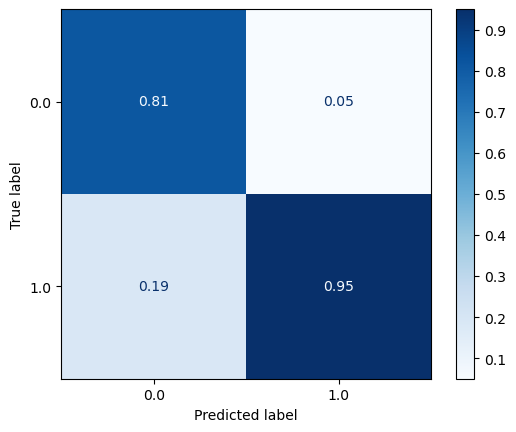

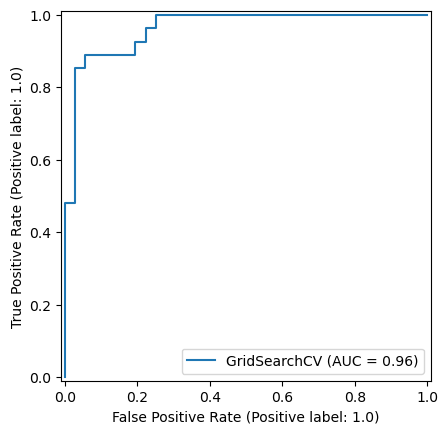

In [51]:
print(f"GridSearchCV best parameters: {grid.best_params_}")
print(f"GridSearchCV best score: {grid.best_score_}")
print(f"GridSearchCV best estimator: {grid.best_estimator_}\n")

print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

cm = ConfusionMatrixDisplay.from_estimator(grid, x_test, y_test, normalize="pred", cmap="Blues")

disp = RocCurveDisplay.from_estimator(grid, x_test, y_test)

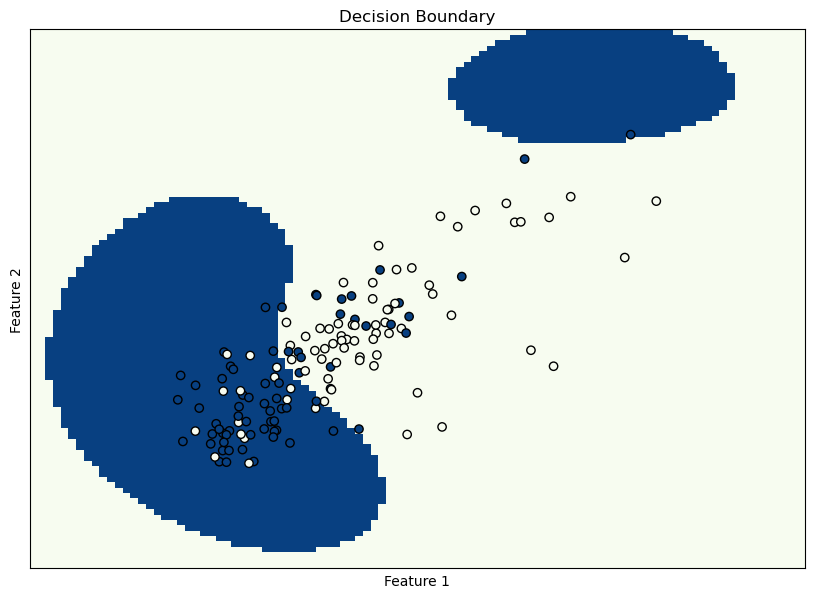

In [52]:
clf = SVC(random_state=42)

sc = StandardScaler()
x_train[:, 10:12] = sc.fit_transform(x_train[:, 10:12])

clf.fit(
    x_train[:, 10:12], y_train
)  # only two features from the dataset to plot the decision boundary
_, ax = plt.subplots(figsize=(10, 7))

DecisionBoundaryDisplay.from_estimator(
    clf,
    x_train[:, 10:12],
    response_method="predict",
    cmap="GnBu",
    ax=ax,
    plot_method="pcolormesh",
    shading="auto",
    xlabel="Feature 1",
    ylabel="Feature 2",
    eps=1.5,
)

plt.scatter(x_train[:, 10], x_train[:, 11], c=y_train, edgecolors="k", cmap="GnBu")

plt.title("Decision Boundary")
plt.xticks(())
plt.yticks(())

plt.show()